# LASV + AAS Gradient Artifact Removal Demo

Este notebook carga un registro simultaneo EEG-fMRI (`fmrirestingec`), excluye opcionalmente el ultimo canal de ECG del pipeline, visualiza la senal EEG antes de la limpieza, ejecuta el metodo `LASV` para resincronizar el reloj EEG con el fMRI, aplica despues `AAS` usando `aas_ga.py` y muestra comparaciones antes y despues.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mne
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from functions.lasv_ga import run_lasv_aas_pipeline

In [2]:
DEFAULT_EEG_ROOT = Path(
    r"C:\Users\pedro\Documents\DOCTORADO_Pedro\Code\phD_Repository\data\raw\Dataset1\Simultaneous_EEG_fMRI\BIDS_dataset_EEG"
)
SUBJECT = "sub-007"
TASK = "fmrirestingec"
TR = 2.0
FS_EXPECTED = 1000.0
EXCLUDE_LAST_CHANNEL = True
INITIAL_H = 1.0
H_BOUNDS = (0.995, 1.005)
LEARNING_RATE = 1e-4
MAX_ITER = 200
TOL = 1e-10
N_ITER_AAS = 20
WINDOW_SIZE_AAS = 101
MAX_LAG_AAS = 10
DISPLAY_SECONDS = 60
USE_FMRI_BOUNDS = False
DISPLAY_CHANNEL = 0

In [3]:
def get_eeg_set_path(subject: str, task: str = TASK, eeg_root: Path = DEFAULT_EEG_ROOT) -> Path:
    eeg_path = eeg_root / subject / "eeg" / f"{subject}_task-{task}_eeg.set"
    if not eeg_path.exists():
        raise FileNotFoundError(f"EEG file not found: {eeg_path}")
    return eeg_path


def load_raw_eeg(eeg_path: Path) -> mne.io.BaseRaw:
    return mne.io.read_raw_eeglab(eeg_path, preload=True, verbose="ERROR")


def prepare_raw_for_pipeline(raw: mne.io.BaseRaw, exclude_last_channel: bool = True) -> mne.io.BaseRaw:
    if exclude_last_channel:
        return raw.copy().pick(raw.ch_names[:-1])
    return raw.copy()


def make_raw_from_array(data: np.ndarray, raw_reference: mne.io.BaseRaw, sfreq: float | None = None) -> mne.io.BaseRaw:
    info = raw_reference.info.copy()
    return mne.io.RawArray(data.copy(), info, verbose="ERROR")


def _window_signal(data: np.ndarray, sfreq: float, duration_s: float) -> tuple[np.ndarray, np.ndarray]:
    n_samples = min(int(round(duration_s * sfreq)), data.shape[-1])
    time = np.arange(n_samples) / sfreq
    return time, data[..., :n_samples]


def plot_before_after(
    raw_before: mne.io.BaseRaw,
    cleaned_data: np.ndarray,
    channel_index: int,
    cleaned_sfreq: float,
    duration_s: float = DISPLAY_SECONDS,
) -> None:
    before = raw_before.get_data(picks=[channel_index])[0]
    after = cleaned_data[channel_index]
    channel_name = raw_before.ch_names[channel_index]

    time_before, before_window = _window_signal(before[np.newaxis, :], float(raw_before.info["sfreq"]), duration_s)
    time_after, after_window = _window_signal(after[np.newaxis, :], cleaned_sfreq, duration_s)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
    axes[0].plot(time_before, before_window[0], linewidth=0.8)
    axes[0].set_title(f"Before LASV + AAS | {channel_name}")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(time_after, after_window[0], linewidth=0.8, color="tab:orange")
    axes[1].set_title(f"After LASV + AAS | {channel_name}")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_overlay_before_after(
    raw_before: mne.io.BaseRaw,
    cleaned_data: np.ndarray,
    channel_index: int,
    cleaned_sfreq: float,
    duration_s: float = DISPLAY_SECONDS,
) -> None:
    before = raw_before.get_data(picks=[channel_index])[0]
    after = cleaned_data[channel_index]
    channel_name = raw_before.ch_names[channel_index]

    time_before, before_window = _window_signal(before[np.newaxis, :], float(raw_before.info["sfreq"]), duration_s)
    time_after, after_window = _window_signal(after[np.newaxis, :], cleaned_sfreq, duration_s)

    plt.figure(figsize=(14, 4))
    plt.plot(time_before, before_window[0], label="Before cleaning", linewidth=0.8, alpha=0.75)
    plt.plot(time_after, after_window[0], label="After LASV + AAS", linewidth=0.8, alpha=0.8)
    plt.title(f"Overlay Before/After | {channel_name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_lasv_objective(result: dict) -> None:
    objective_history = np.asarray(result["optimization"]["objective_history"], dtype=float)
    h_history = np.asarray(result["optimization"]["h_history"], dtype=float)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
    axes[0].plot(np.arange(objective_history.size), objective_history, marker="o", markersize=3, linewidth=0.8)
    axes[0].set_title("LASV objective J(h) during optimization")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("J(h)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(np.arange(h_history.size), h_history, marker="o", markersize=3, linewidth=0.8, color="tab:green")
    axes[1].set_title("LASV scale factor h during optimization")
    axes[1].set_xlabel("Accepted step")
    axes[1].set_ylabel("h")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_segment_template_comparison(result: dict, channel_index: int) -> None:
    template = result["aas"]["final_reference_template"]
    raw_segment = result["aas"]["segmented_signal"][channel_index, 0]
    aligned_segment = result["aas"]["aligned_segments"][channel_index, 0]
    cleaned_segment = result["aas"]["cleaned_segments"][channel_index, 0]
    samples = np.arange(template.shape[0])

    plt.figure(figsize=(14, 5))
    plt.plot(samples, raw_segment, label="Resampled segment", linewidth=0.8, alpha=0.8)
    plt.plot(samples, aligned_segment, label="Aligned segment", linewidth=0.8, alpha=0.8)
    plt.plot(samples, template, label="Final reference template", linewidth=1.2)
    plt.plot(samples, cleaned_segment, label="Cleaned segment", linewidth=0.8, alpha=0.8)
    plt.title("Segment and Template Comparison after LASV")
    plt.xlabel("Samples within TR")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [4]:
eeg_path = get_eeg_set_path(SUBJECT)
raw = load_raw_eeg(eeg_path)
raw_eeg = prepare_raw_for_pipeline(raw, exclude_last_channel=EXCLUDE_LAST_CHANNEL)
eeg_data = raw_eeg.get_data()
fs = float(raw_eeg.info["sfreq"])

if fs != FS_EXPECTED:
    raise ValueError(f"This demo expects fs={FS_EXPECTED} Hz, but found {fs} Hz.")

print(f"Subject: {SUBJECT}")
print(f"Task: {TASK}")
print(f"EEG path: {eeg_path}")
print(f"Original shape: {raw.get_data().shape}")
print(f"LASV input shape: {eeg_data.shape}")
print(f"Sampling frequency: {fs} Hz")
if EXCLUDE_LAST_CHANNEL:
    print(f"Excluded channel: {raw.ch_names[-1]}")

Subject: sub-007
Task: fmrirestingec
EEG path: C:\Users\pedro\Documents\DOCTORADO_Pedro\Code\phD_Repository\data\raw\Dataset1\Simultaneous_EEG_fMRI\BIDS_dataset_EEG\sub-007\eeg\sub-007_task-fmrirestingec_eeg.set
Original shape: (33, 628889)
LASV input shape: (32, 628889)
Sampling frequency: 1000.0 Hz
Excluded channel: ECG


## Visualizacion antes de limpiar

In [5]:
mne.viz.set_browser_backend("qt")
raw_eeg.plot(
    n_channels=20,
    duration=10,
    show_scrollbars=True,
    block=True,
)

Using qt as 2D backend.
Channels marked as bad:
none


## Aplicacion del pipeline LASV + AAS

In [6]:
result = run_lasv_aas_pipeline(
    signal=eeg_data,
    fs=fs,
    tr=TR,
    use_fmri_bounds=USE_FMRI_BOUNDS,
    learning_rate=LEARNING_RATE,
    max_iter=MAX_ITER,
    tol=TOL,
    h_bounds=H_BOUNDS,
    initial_h=INITIAL_H,
    n_iter_aas=N_ITER_AAS,
    window_size_aas=WINDOW_SIZE_AAS,
    max_lag_aas=MAX_LAG_AAS,
)

cleaned_eeg = result["cleaned_signal"]
resampled_eeg = result["resampled_signal"]
reference_channel = result["reference_channel"]
fs_opt = result["fs_opt"]

print(f"Automatically selected reference channel: {reference_channel} ({raw_eeg.ch_names[reference_channel]})")
print(f"Optimized h: {result['h_opt']:.12f}")
print(f"Original fs: {result['fs_original']} Hz")
print(f"Optimized fs: {fs_opt:.12f} Hz")
print(f"Original samples per TR: {result['tr_samples_original']}")
print(f"Optimized samples per TR: {result['tr_samples_opt']}")
print(f"Estimated offset after LASV: {result['offset_opt']} samples")
print(f"Resampled EEG shape: {resampled_eeg.shape}")
print(f"Cleaned EEG shape: {cleaned_eeg.shape}")
print(f"Final objective J(h): {result['optimization']['objective']:.6f}")
print(f"Use fMRI bounds: {result['use_fmri_bounds']}")
if result["use_fmri_bounds"]:
    print(f"fMRI start (original): sample {result['fmri_start_sample']} | {result['fmri_start_time_sec']:.6f} s")
    print(f"fMRI end (original): sample {result['fmri_end_sample']} | {result['fmri_end_time_sec']:.6f} s")
    print(f"fMRI start (resampled): sample {result['fmri_start_sample_resampled']} | {result['fmri_start_time_sec_resampled']:.6f} s")
    print(f"fMRI end (resampled): sample {result['fmri_end_sample_resampled']} | {result['fmri_end_time_sec_resampled']:.6f} s")
else:
    print("Processing full EEG signal without fMRI start/end detection.")


Automatically selected reference channel: 20 (E21)
Optimized h: 1.000000047324
Original fs: 1000.0 Hz
Optimized fs: 1000.000047324496 Hz
Original samples per TR: 2000
Optimized samples per TR: 2000
Estimated offset after LASV: 1999 samples
Resampled EEG shape: (32, 628889)
Cleaned EEG shape: (32, 628889)
Final objective J(h): 0.000000
Use fMRI bounds: False
Processing full EEG signal without fMRI start/end detection.


## Intervalo fMRI detectado

Muestra el inicio y fin del bloque fMRI detectado automaticamente por el pipeline LASV + AAS.


In [7]:
if result["use_fmri_bounds"]:
    print(f"fMRI interval (original EEG): {result['fmri_start_time_sec']:.6f} s -> {result['fmri_end_time_sec']:.6f} s")
    print(f"fMRI interval (original samples): {result['fmri_start_sample']} -> {result['fmri_end_sample']}")
    print(f"fMRI interval (LASV resampled): {result['fmri_start_time_sec_resampled']:.6f} s -> {result['fmri_end_time_sec_resampled']:.6f} s")
    print(f"fMRI interval (LASV resampled samples): {result['fmri_start_sample_resampled']} -> {result['fmri_end_sample_resampled']}")
else:
    print("USE_FMRI_BOUNDS=False: se procesa toda la señal EEG.")


USE_FMRI_BOUNDS=False: se procesa toda la señal EEG.


## Visualizacion despues de limpiar

In [8]:
raw_resampled = make_raw_from_array(resampled_eeg, raw_eeg, sfreq=fs_opt)
raw_clean = make_raw_from_array(cleaned_eeg, raw_eeg, sfreq=fs_opt)

In [9]:
raw_clean.plot(
    n_channels=20,
    duration=10,
    show_scrollbars=True,
    block=True,
)

Channels marked as bad:
none


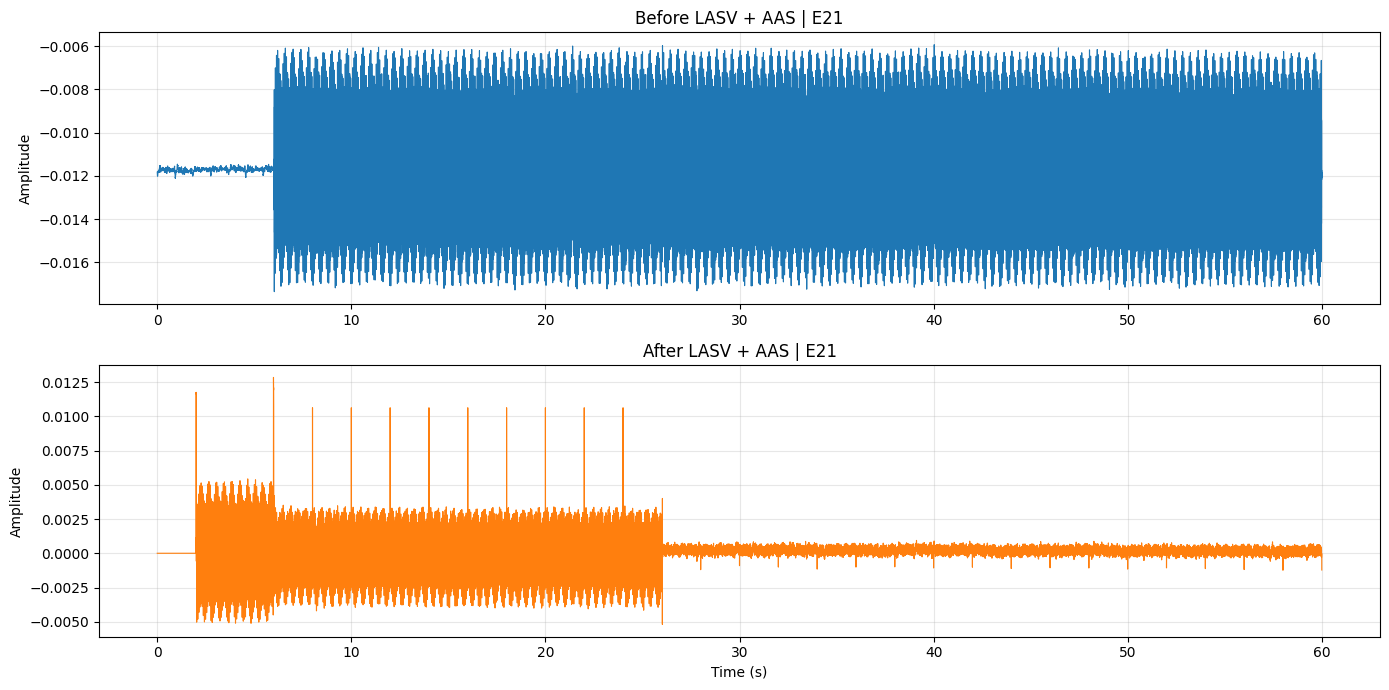

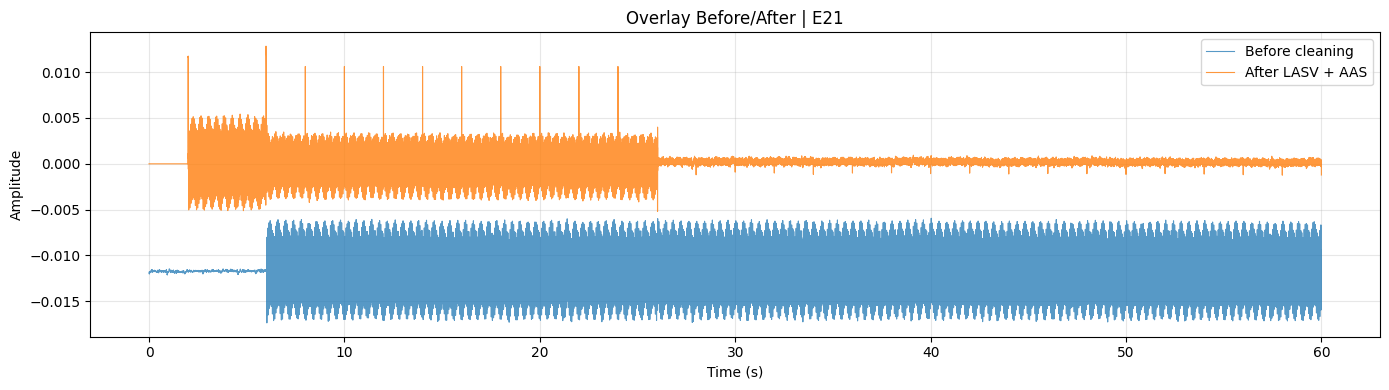

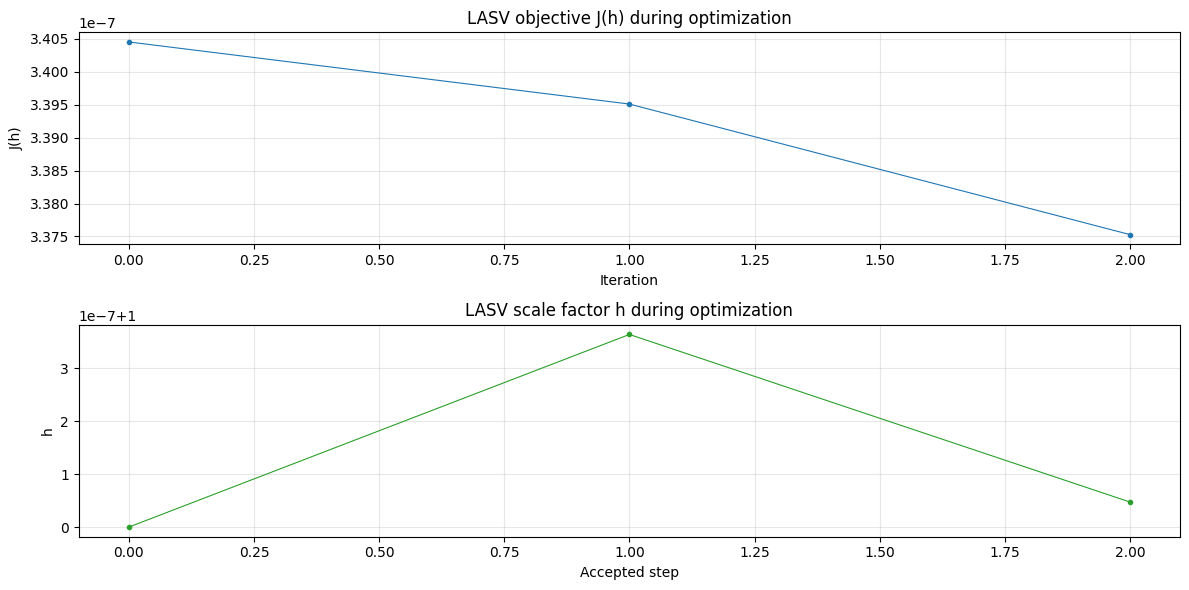

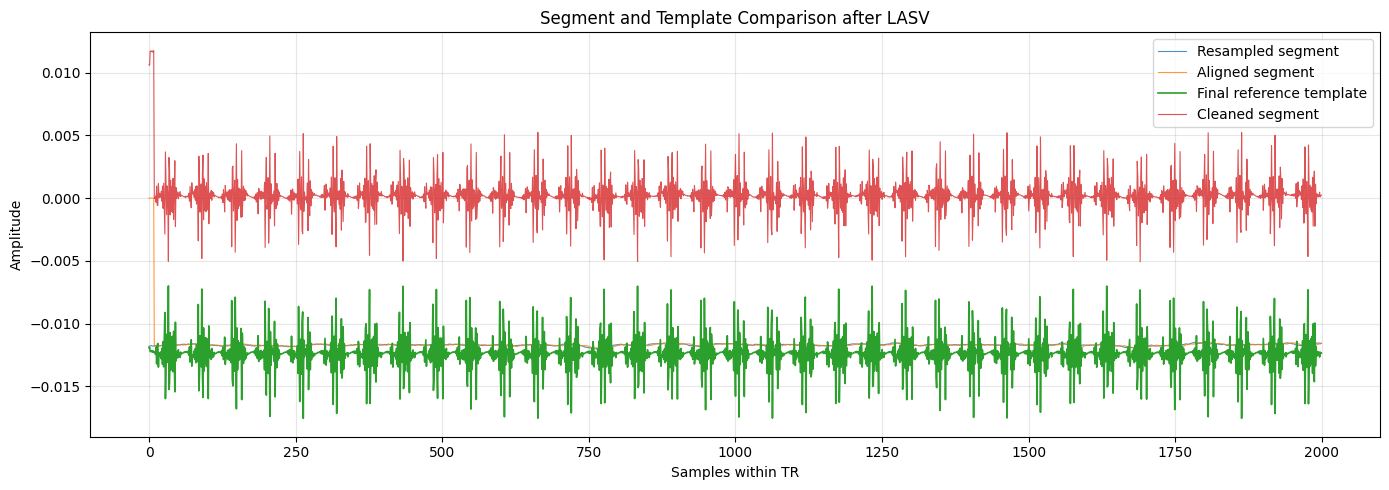

In [10]:
plot_before_after(raw_eeg, cleaned_eeg, channel_index=reference_channel, cleaned_sfreq=fs_opt, duration_s=DISPLAY_SECONDS)
plot_overlay_before_after(raw_eeg, cleaned_eeg, channel_index=reference_channel, cleaned_sfreq=fs_opt, duration_s=DISPLAY_SECONDS)
plot_lasv_objective(result)
plot_segment_template_comparison(result, channel_index=reference_channel)